Генерация гравитационно-волнового сигнала (Chirp)

В этом ноутбуке я моделирую сигнал гравитационных волн от слияния двух чёрных дыр звёздных масс (по 30 масс Солнца каждое), аналогично историческому событию GW150914.

Ключевые параметры:
- **Чирп-масса ($\mathcal{M}$)**: эффективная масса, определяющая скорость сближения.
- **Частота ($f$)**: растёт по мере сближения объектов
- **Амплитуда ($h$)**: также нарастает, достигая максимума в момент слияния.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-darkgrid') 

In [2]:
G = 6.67430e-11
c = 299792458
M_sun = 1.98847e30

m1, m2 = 30, 30
fs = 4096
duration = 2.0

print(f"Моделирование слияния: {m1} M☉ + {m2} M☉")

Моделирование слияния: 30 M☉ + 30 M☉


## Расчёт сигнала

Вычисляем чирп-массу, эволюцию частоты, фазу и амплитуду сигнала.

In [ ]:
m1_kg = m1 * M_sun
m2_kg = m2 * M_sun
mc = ((m1_kg * m2_kg) ** (3/5)) / ((m1_kg + m2_kg) ** (1/5))

t = np.linspace(0, duration, int(fs * duration), endpoint=False)
tc = duration + 0.005
tau = tc - t

f = (1 / np.pi) * (5 / (256 * tau)) ** (3/8) * (G * mc / c**3) ** (-5/8)
phi = 2 * np.pi * np.cumsum(f) / fs

amplitude = (tau / tau[0]) ** (-1/4)
h = amplitude * np.cos(phi)
h = h / np.max(np.abs(h))

print(f"✅ Сигнал сгенерирован! Длина: {len(t)} точек.")
print(f"Чирп-масса: {mc / M_sun:.2f} M☉")

✅ Сигнал сгенерирован! Длина: 8192 точек.
Чирп-масса: 26.12 M☉


## Визуализация сигнала

Строим два графика: форму волны во времени и эволюцию частоты.

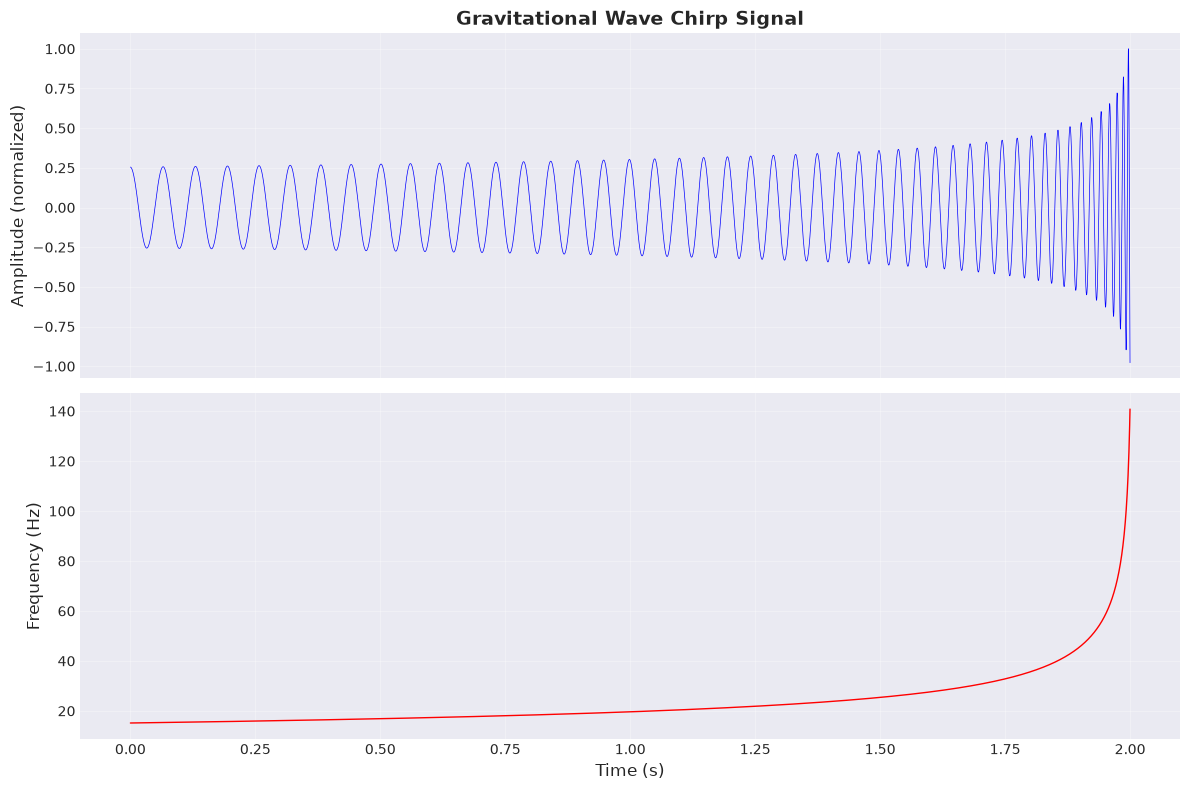

In [4]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

ax1.plot(t, h, color='blue', linewidth=0.5)
ax1.set_title('Gravitational Wave Chirp Signal', fontsize=14, fontweight='bold')
ax1.set_ylabel('Amplitude (normalized)', fontsize=12)
ax1.grid(True, alpha=0.3)

ax2.plot(t, f, color='red', linewidth=1)
ax2.set_xlabel('Time (s)', fontsize=12)
ax2.set_ylabel('Frequency (Hz)', fontsize=12)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Спектрограмма сигнала

Спектрограмма показывает, как меняется частота сигнала во времени. Цветом обозначена интенсивность.

По оси X — время, по оси Y — частота (Гц), цвет — мощность сигнала.

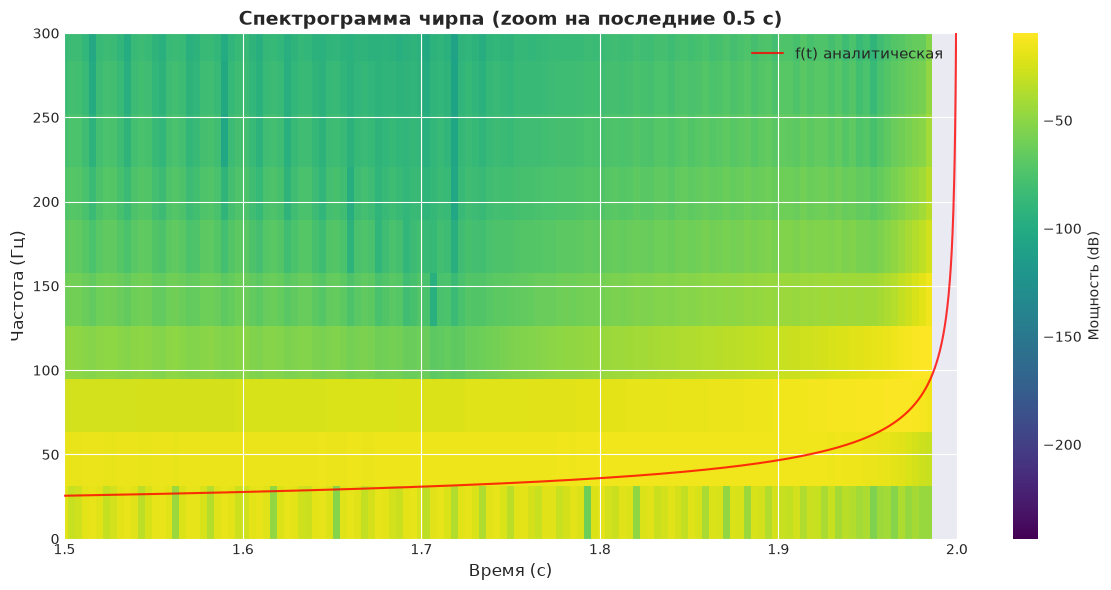

In [23]:
# === ИСПРАВЛЕННАЯ СПЕКТРОГРАММА ===

# Приближаем момент слияния к концу записи
tc = duration + 1/fs
tau = tc - t

# Пересчитываем частоту и фазу
f = (1 / np.pi) * (5 / (256 * tau)) ** (3/8) * (G * mc / c**3) ** (-5/8)
phi = 2 * np.pi * np.cumsum(f) / fs

# Сигнал БЕЗ нормировки
h_raw = (tau / tau[0]) ** (-1/4) * np.cos(phi)

# Строим спектрограмму
fig, ax = plt.subplots(figsize=(12, 6))

# ВАЖНО: сохраняем возвращаемые значения, особенно im для colorbar
spectrum, freqs, t_spec, im = ax.specgram(
    h_raw, Fs=fs, NFFT=128, noverlap=112, cmap='viridis', scale='dB'
)

# Накладываем аналитическую кривую
ax.plot(t, f, color='red', linewidth=1.5, alpha=0.8, label='f(t) аналитическая')

# Zoom на последние 0.5 секунды
ax.set_xlim(1.5, duration)
ax.set_ylim(0, 300)

ax.set_ylabel('Частота (Гц)', fontsize=12)
ax.set_xlabel('Время (с)', fontsize=12)
ax.set_title('Спектрограмма чирпа (zoom на последние 0.5 с)', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)

# Теперь im определён, colorbar работает
fig.colorbar(im, ax=ax, label='Мощность (dB)')

plt.tight_layout()
plt.show()

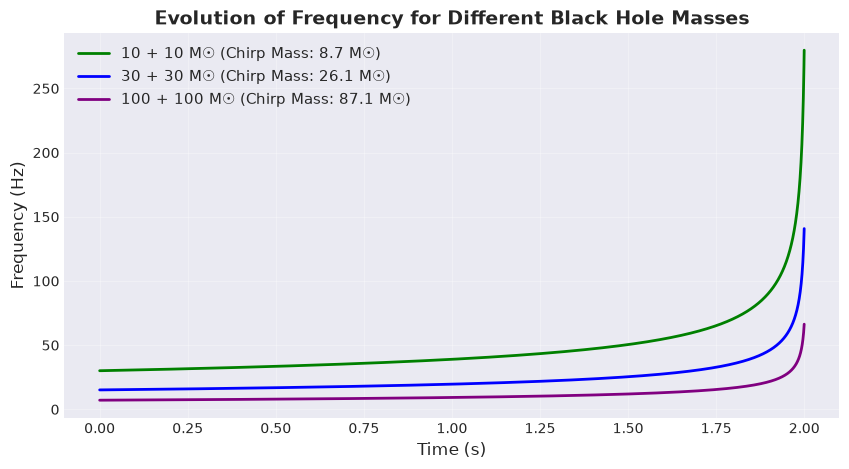

In [13]:
masses_to_compare = [(10, 10), (30, 30), (100, 100)]
colors = ['green', 'blue', 'purple']

plt.figure(figsize=(10, 5))

for (m1_test, m2_test), color in zip(masses_to_compare, colors):
    m1_kg_test = m1_test * M_sun
    m2_kg_test = m2_test * M_sun
    mc_test = ((m1_kg_test * m2_kg_test) ** (3/5)) / ((m1_kg_test + m2_kg_test) ** (1/5))
    
    tau_test = tc - t
    f_test = (1 / np.pi) * (5 / (256 * tau_test)) ** (3/8) * (G * mc_test / c**3) ** (-5/8)
    
    plt.plot(t, f_test, color=color, linewidth=2, label=f'{m1_test} + {m2_test} M☉ (Chirp Mass: {mc_test/M_sun:.1f} M☉)')

plt.xlabel('Time (s)', fontsize=12)
plt.ylabel('Frequency (Hz)', fontsize=12)
plt.title('Evolution of Frequency for Different Black Hole Masses', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.show()